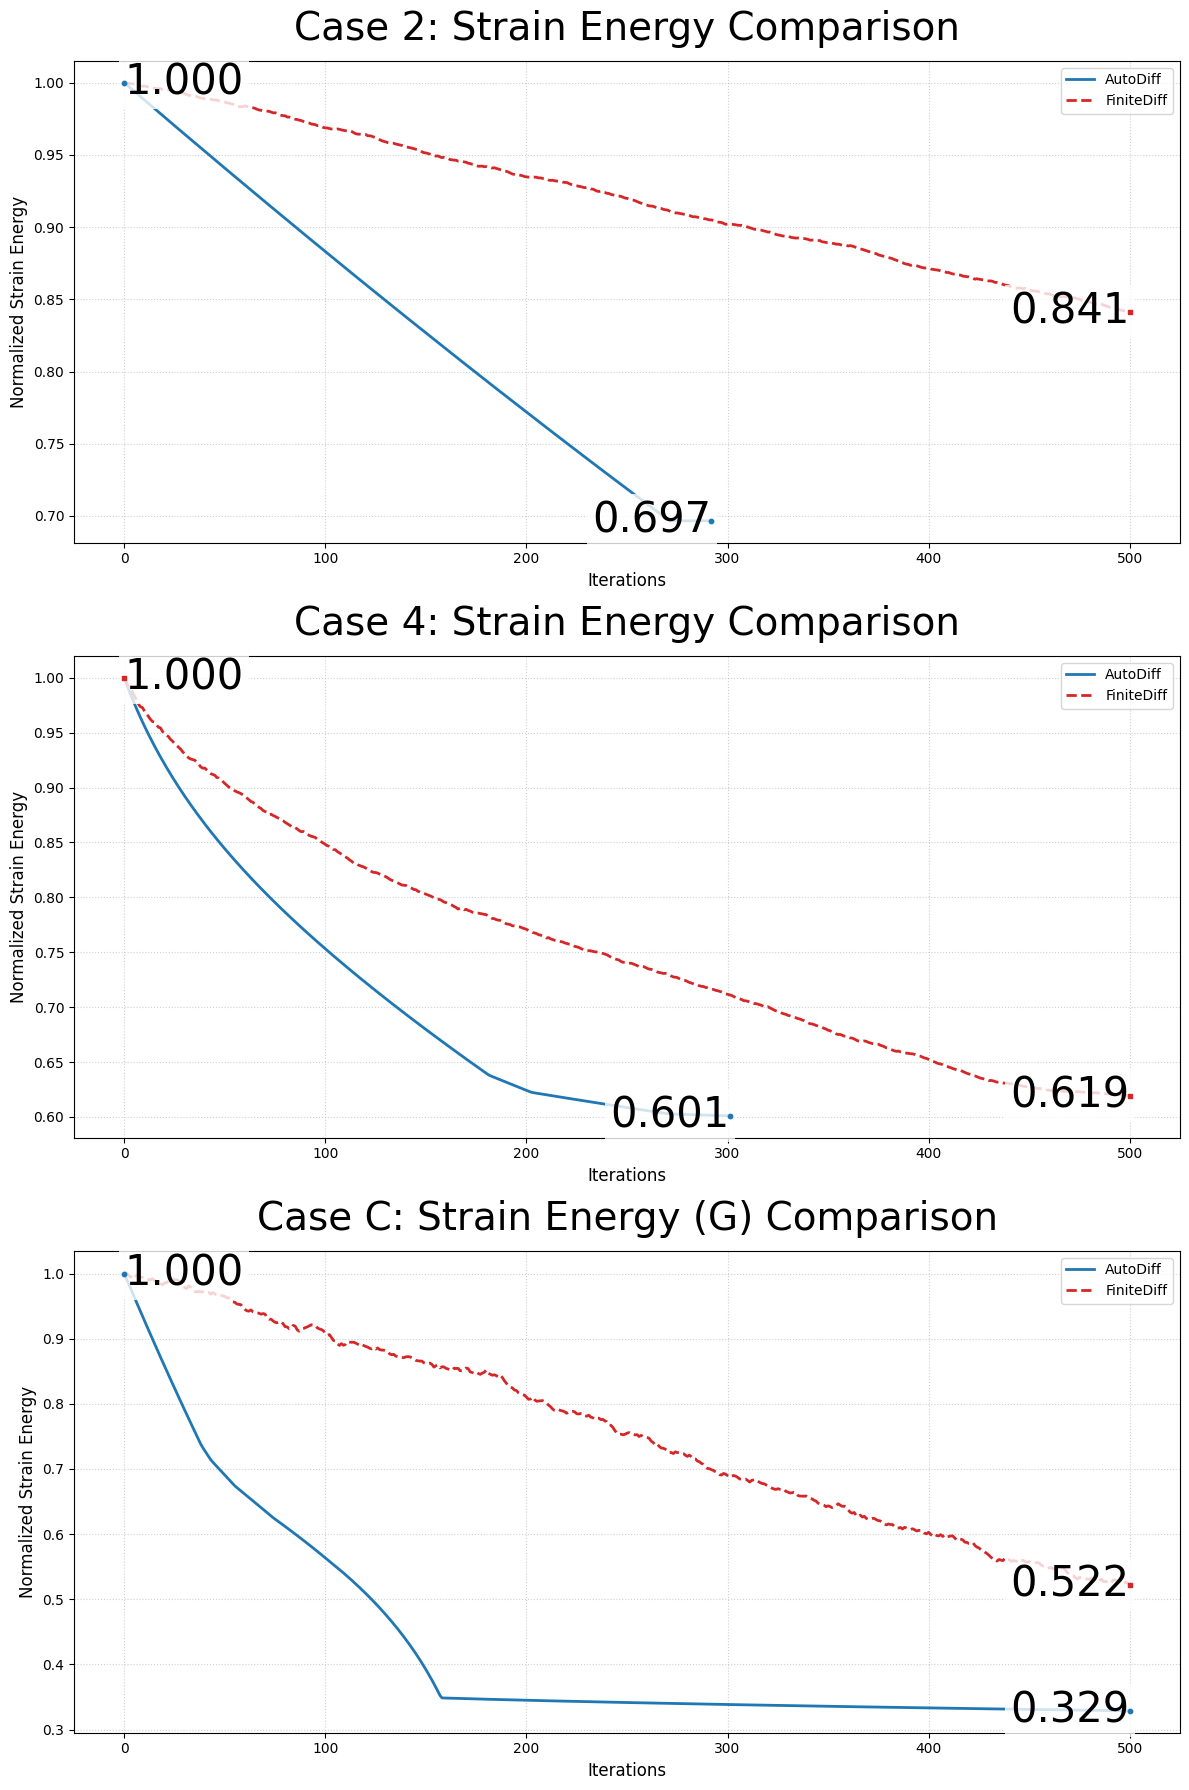

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_data(ad_file, fd_file, ad_key, fd_key):
    # Load AutoDiff data
    with open(ad_file, 'r') as f:
        ad_data = json.load(f)
    ad_strain_energy = []
    for item in ad_data['iterations']:
        if ad_key in item:
            ad_strain_energy.append(item[ad_key])
        else:
            raise KeyError(f"Key '{ad_key}' not found in {ad_file}. Available keys: {item.keys()}")
    
    # Load FiniteDiff data
    with open(fd_file, 'r') as f:
        fd_data = json.load(f)
    fd_strain_energy = []
    for item in fd_data['iterations']:
        if fd_key in item:
            fd_strain_energy.append(item[fd_key])
        else:
            raise KeyError(f"Key '{fd_key}' not found in {fd_file}. Available keys: {item.keys()}")
    
    return ad_strain_energy, fd_strain_energy

try:
    # Load data with different keys for different cases
    ad2, fd2 = load_data('AD2_data.json', 'FD2_data.json', 'strain_energy', 'strain_energy')
    ad4, fd4 = load_data('AD4_data.json', 'FD4_data.json', 'strain_energy', 'strain_energy')
    adc, fdc = load_data('ADC_data.json', 'FDC_data.json', 'strain_energy_g', 'strain_energy_g')
except Exception as e:
    print(f"Error loading data: {e}")
    # Debugging: Print structure of first file
    try:
        print("\nDebugging info for AD2_data.json:")
        with open('AD2_data.json', 'r') as f:
            sample = json.load(f)
            print("First iteration keys:", sample['iterations'][0].keys())
    except:
        print("Could not examine AD2_data.json")
    exit()

# Normalize strain energy data (divided by initial value)
def normalize(data):
    if len(data) == 0:
        return data
    initial_value = data[0]
    return [x / initial_value for x in data]

ad2_norm = normalize(ad2)
fd2_norm = normalize(fd2)
ad4_norm = normalize(ad4)
fd4_norm = normalize(fd4)
adc_norm = normalize(adc)
fdc_norm = normalize(fdc)

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

def plot_comparison(ax, ad_data, fd_data, title):
    color1 = 'tab:blue'
    color2 = 'tab:red'
    
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Normalized Strain Energy', color='black', fontsize=12)
    
    # Plot lines
    if len(ad_data) > 0:
        ax.plot(ad_data, label='AutoDiff', color=color1, linewidth=2, linestyle='-')
    if len(fd_data) > 0:
        ax.plot(fd_data, label='FiniteDiff', color=color2, linewidth=2, linestyle='--')
    
    # Function to add markers with just values
    def add_markers(data, color, show_initial, marker='o'):
        if len(data) > 0:
            # Only show initial value if show_initial is True
            if show_initial:
                ax.scatter(0, data[0], color=color, zorder=5, s=10, marker=marker)
                ax.text(0, data[0], f'{data[0]:.3f}',
                       ha='left', va='center',
                       fontsize=30, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
            # Always show final value
            ax.scatter(len(data)-1, data[-1], color=color, zorder=5, s=10, marker=marker)
            ax.text(len(data)-1, data[-1], f'{data[-1]:.3f}',
                   ha='right', va='center',
                   fontsize=30, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # For each subplot, alternate which dataset shows initial value
    if ax == ax1:
        # Case 2: Show AutoDiff initial value
        add_markers(ad_data, color1, True)
        add_markers(fd_data, color2, False, marker='s')
    elif ax == ax2:
        # Case 4: Show FiniteDiff initial value
        add_markers(ad_data, color1, False)
        add_markers(fd_data, color2, True, marker='s')
    else:
        # Case C: Show AutoDiff initial value
        add_markers(ad_data, color1, True)
        add_markers(fd_data, color2, False, marker='s')
    
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_title(title, fontsize=28, pad=15)
    
    # Set y-axis limits
    combined = ad_data + fd_data
    if len(combined) > 0:
        data_min = min(combined)
        data_max = max(combined)
        margin = 0.05 * (data_max - data_min)
        y_min = data_min - margin
        y_max = data_max + margin
        ax.set_ylim(y_min, y_max)

# Plot each comparison
plot_comparison(ax1, ad2_norm, fd2_norm, 'Case 2: Strain Energy Comparison')
plot_comparison(ax2, ad4_norm, fd4_norm, 'Case 4: Strain Energy Comparison')
plot_comparison(ax3, adc_norm, fdc_norm, 'Case C: Strain Energy (G) Comparison')

plt.tight_layout()
plt.savefig('strain_energy_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

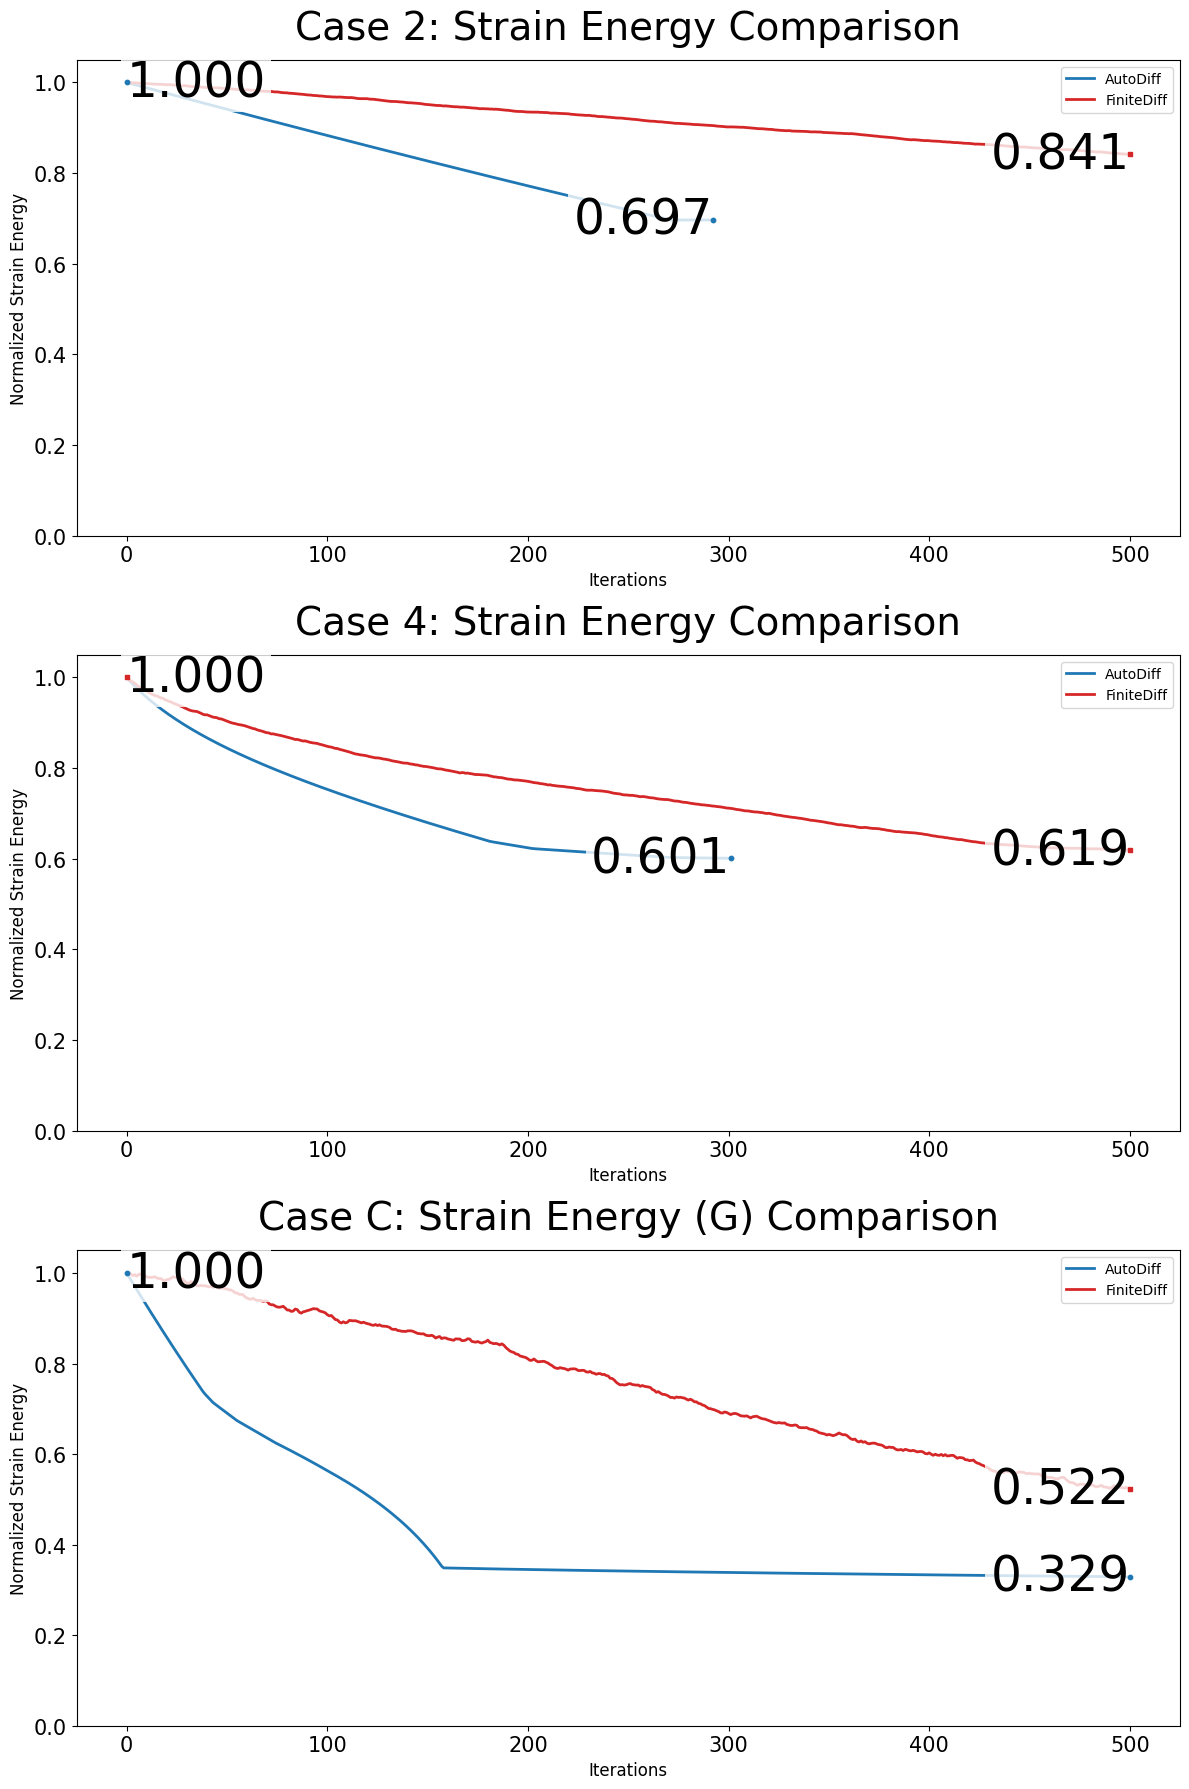

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_data(ad_file, fd_file, ad_key, fd_key):
    # Load AutoDiff data
    with open(ad_file, 'r') as f:
        ad_data = json.load(f)
    ad_strain_energy = []
    for item in ad_data['iterations']:
        if ad_key in item:
            ad_strain_energy.append(item[ad_key])
        else:
            raise KeyError(f"Key '{ad_key}' not found in {ad_file}. Available keys: {item.keys()}")
    
    # Load FiniteDiff data
    with open(fd_file, 'r') as f:
        fd_data = json.load(f)
    fd_strain_energy = []
    for item in fd_data['iterations']:
        if fd_key in item:
            fd_strain_energy.append(item[fd_key])
        else:
            raise KeyError(f"Key '{fd_key}' not found in {fd_file}. Available keys: {item.keys()}")
    
    return ad_strain_energy, fd_strain_energy

try:
    # Load data with different keys for different cases
    ad2, fd2 = load_data('AD2_data.json', 'FD2_data.json', 'strain_energy', 'strain_energy')
    ad4, fd4 = load_data('AD4_data.json', 'FD4_data.json', 'strain_energy', 'strain_energy')
    adc, fdc = load_data('ADC_data.json', 'FDC_data.json', 'strain_energy_g', 'strain_energy_g')
except Exception as e:
    print(f"Error loading data: {e}")
    # Debugging: Print structure of first file
    try:
        print("\nDebugging info for AD2_data.json:")
        with open('AD2_data.json', 'r') as f:
            sample = json.load(f)
            print("First iteration keys:", sample['iterations'][0].keys())
    except:
        print("Could not examine AD2_data.json")
    exit()

# Normalize strain energy data (divided by initial value)
def normalize(data):
    if len(data) == 0:
        return data
    initial_value = data[0]
    return [x / initial_value for x in data]

ad2_norm = normalize(ad2)
fd2_norm = normalize(fd2)
ad4_norm = normalize(ad4)
fd4_norm = normalize(fd4)
adc_norm = normalize(adc)
fdc_norm = normalize(fdc)

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

def plot_comparison(ax, ad_data, fd_data, title):
    color1 = 'tab:blue'
    color2 = 'tab:red'
    
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Normalized Strain Energy', color='black', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=15) 
    
    # Plot lines
    if len(ad_data) > 0:
        ax.plot(ad_data, label='AutoDiff', color=color1, linewidth=2, linestyle='-')
    if len(fd_data) > 0:
        ax.plot(fd_data, label='FiniteDiff', color=color2, linewidth=2, linestyle='-')
    
    # Function to add markers with just values
    def add_markers(data, color, show_initial, marker='o'):
        if len(data) > 0:
            # Only show initial value if show_initial is True
            if show_initial:
                ax.scatter(0, data[0], color=color, zorder=5, s=10, marker=marker)
                ax.text(0, data[0], f'{data[0]:.3f}',
                       ha='left', va='center',
                       fontsize=35, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
            # Always show final value
            ax.scatter(len(data)-1, data[-1], color=color, zorder=5, s=10, marker=marker)
            ax.text(len(data)-1, data[-1], f'{data[-1]:.3f}',
                   ha='right', va='center',
                   fontsize=35, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # For each subplot, alternate which dataset shows initial value
    if ax == ax1:
        # Case 2: Show AutoDiff initial value
        add_markers(ad_data, color1, True)
        add_markers(fd_data, color2, False, marker='s')
    elif ax == ax2:
        # Case 4: Show FiniteDiff initial value
        add_markers(ad_data, color1, False)
        add_markers(fd_data, color2, True, marker='s')
    else:
        # Case C: Show AutoDiff initial value
        add_markers(ad_data, color1, True)
        add_markers(fd_data, color2, False, marker='s')
    
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(title, fontsize=28, pad=15)
    
    # Set y-axis limits - starting from 0
    combined = ad_data + fd_data
    if len(combined) > 0:
        data_max = max(combined)
        # Set y_min to 0 and y_max to 5% above the maximum value
        y_min = 0
        y_max = data_max * 1.05
        ax.set_ylim(y_min, y_max)

# Plot each comparison
plot_comparison(ax1, ad2_norm, fd2_norm, 'Case 2: Strain Energy Comparison')
plot_comparison(ax2, ad4_norm, fd4_norm, 'Case 4: Strain Energy Comparison')
plot_comparison(ax3, adc_norm, fdc_norm, 'Case C: Strain Energy (G) Comparison')

plt.tight_layout()
plt.savefig('strain_energy_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [6]:
def plot_comparison(ax, ad_data, fd_data, title):
    color1 = 'tab:blue'
    color2 = 'tab:red'
    
    ax.set_xlabel('Iterations', fontsize=12)
    ax.set_ylabel('Normalized Strain Energy', color='black', fontsize=12)
    
    # 设置x轴和y轴刻度标签大小
    ax.tick_params(axis='both', which='major', labelsize=15)
    
    # Plot lines
    if len(ad_data) > 0:
        ax.plot(ad_data, label='AutoDiff', color=color1, linewidth=2, linestyle='-')
    if len(fd_data) > 0:
        ax.plot(fd_data, label='FiniteDiff', color=color2, linewidth=2, linestyle='-')
    
    # 其余代码保持不变...
    # Function to add markers with just values
    def add_markers(data, color, show_initial, marker='o'):
        if len(data) > 0:
            # Only show initial value if show_initial is True
            if show_initial:
                ax.scatter(0, data[0], color=color, zorder=5, s=10, marker=marker)
                ax.text(0, data[0], f'{data[0]:.3f}',
                       ha='left', va='center',
                       fontsize=30, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
            # Always show final value
            ax.scatter(len(data)-1, data[-1], color=color, zorder=5, s=10, marker=marker)
            ax.text(len(data)-1, data[-1], f'{data[-1]:.3f}',
                   ha='right', va='center',
                   fontsize=30, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    # For each subplot, alternate which dataset shows initial value
    if ax == ax1:
        # Case 2: Show AutoDiff initial value
        add_markers(ad_data, color1, True)
        add_markers(fd_data, color2, False, marker='s')
    elif ax == ax2:
        # Case 4: Show FiniteDiff initial value
        add_markers(ad_data, color1, False)
        add_markers(fd_data, color2, True, marker='s')
    else:
        # Case C: Show AutoDiff initial value
        add_markers(ad_data, color1, True)
        add_markers(fd_data, color2, False, marker='s')
    
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(title, fontsize=28, pad=15)
    
    # Set y-axis limits - starting from 0
    combined = ad_data + fd_data
    if len(combined) > 0:
        data_max = max(combined)
        # Set y_min to 0 and y_max to 5% above the maximum value
        y_min = 0
        y_max = data_max * 1.05
        ax.set_ylim(y_min, y_max)